## **Project Title**
**Dataset:** This Jupyter Notebook focuses on **Exploratory Data Analysis (EDA)** of the **Cape Town Incidents**. It encompasses generating visualizations, exploring different aspects of the dataset, and documenting findings.

**Objective:** The primary aim of this project is to uncover and explain insights into the characteristics, trends, and patterns present in the **Cape Town Incidents**. A comprehensive report on the findings in this Jupyter Notebook can be found in the **CapeTown_Incidents_EDA_ Doc.pdf** document. You can access the report on my GitHub portfolio in the same folder where this notebook is located.
## **Table of Contents**
0. [Import Libraries](#0-Import-libraries)

1. [Import Data](#1-import-data)

2. [Dataset Overview](#2-dataset-overview)
   * [2.1 Data Inspection](#21-data-inspection)

3. [Data Cleaning](#3-data-cleaning)
   * [3.1 Reshaping the Dataset](#31-reshaping-the-dataset)
   * [3.2 Standardizing Missing Values](#32-standardizing-missing-values) 
   * [3.3 Splitting Incident Categories](#33-splitting-incident-categories)
   * [3.4 Missing Value Analysis](#34-missing-value-analysis)
   * [3.5 Handling Missing Values](#35-handling-missing-values)
   * [3.6 Standardization of Incident Categories](#36-standardization-of-Incident-Categories)  
   * [3.7 Final Cleaned Dataset](#37-final-cleaned-dataset)

4. [Data Preparation for Analysis](#4-data-preparation-for-analysis)
   * [4.1 Data Integration](#41-data-integration)
      * [4.1.1 Suburb Lookup Table](#411-suburb-lookup-table)
      * [4.1.2 GeoJSON Spatial Dataset](#412-geojson-spatial-dataset)
   * [4.2 Category Consolodidation](#42-category-consolidation)
   * [4.3 Final Analytical Dataset](#43-final-analytical-dataset)

5. [Exploratory Data Analysis](#5-exploratory-data-analysis)
   * [5.1 Incident Category Distribution](#51-incidents-category-distribution)
   * [5.2 Temporal Analysis](#52-temporal-analysis)
      * [5.2.1 Incidents by Month](#521-incidents-by-month)
      * [5.2.2 Seasonal Trends For Major Categories](#522-seasonal-trends-for-major-categories)
      * [5.2.3 Incidents by Day Type](#523-incidents-by-day-type)
   * [5.3 Spatial Analysis](#53-spatial-analysis)
      * [5.3.1 Spatial Distribution of Incidents](#531-spatial-distribution-of-incidents )
      * [5.3.2 Suburbs with highest demand?](#543-suburbs-with-highest-demand?)
      * [5.3.3 Top 10 high-incident suburbs](#533-top-10-high-incident-suburbs)
   * [5.3 Key Findings and Business Recommendations](#54-key-findings-and-business-recommendations)
  



### **0. Import Libraries**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import geopandas as gpd #to read and process geospatial data
import plotly.express as px
import mapclassify

# 21 colours, dark to light
more_than_10 = sns.color_palette("GnBu_r", 21)
 

colors = [
    "#F2F9F1",
    "#DCEFD8",
    "#BFE3C6",
    "#8FD1B2",
    "#63BCA6",
    "#3FA7C6",
    "#1F78B4",
    "#08519C"
]

cmap = LinearSegmentedColormap.from_list("green_blue", colors)

# Generate 21 colours
palette_21 = [cmap(i / 20) for i in range(20, -1, -1)]

# Grey for less than 10 occurances of incidents
palette_less10= "#D9D9D9"

# to enable inline plotting for Jupyter notebooks
%matplotlib inline 

### **1. Import Data**

In [5]:

# incidents dataset
data_cpt =pd.read_csv("data/data_cpt.csv")
# lookup suburb dataset
data_suburb = pd.read_csv("data/lookup.csv")
# geojson map dataset
data_geojson =gpd.read_file("data/CapeTownMap.geojson")


### **2. Dataset Overview**

The city of Cape Town makes various data available to the public on the [Open Data Portal](https://odp-cctegis.opendata.arcgis.com/). This dataset specifically relates to incidents reported across suburbs within the municipality. When an incident is reported, a unique ID is assigned to the case along with the date. It then gets categorized by its main category, subcategory, and the suburb where the report is coming from. In addition to the incident dataset, a lookup.csv file containing suburb IDs and their corresponding suburb names, and a CapeTown.geojson file containing the geographic boundaries of Cape Town suburbs, were also downloaded. The lookup file facilitates the mapping of suburb identifiers to descriptive names, while the GeoJSON file enables the integration of the incident data with geographic boundaries for spatial analysis and visualization.

#### **2.1 Data inspection**
Initial inspection of the dataset shows that it is in a wide format, consisting of 18,980 rows and 167 columns. Each row represents a reported incident, while most columns correspond to incident subcategories, with the associated main category and subcategory combined into a single column name separated by a hyphen ("-").

For a given day and suburb, one or more incident category columns may contain a numeric value representing the number of reported incidents for that category. The remaining incident category columns contain the value "?", indicating that no incidents were recorded for those categories on that day in that suburb.

The ID column serves only as a unique identifier for each incident and is not expected to contribute to the analysis. The Day, Month, and Suburb variables are stored as integers, whereas the incident category columns are stored as objects.

At this stage, it is difficult to determine the presence of missing values, duplicate records, or redundant variables because the dataset is still in its original wide format. These aspects will be assessed more effectively after the data has been cleaned and transformed into a more suitable structure for analysis.

In [6]:
# total rows x columns
print(f"The data has (#no of rows, #no of columns) = {data_cpt.shape}")

# types of columns
print(data_cpt.dtypes)

# list of names of columns
print(data_cpt.columns)

# info about the data
print(data_cpt.info())

# view the first 5 rows of the data
data_cpt.head(10)

The data has (#no of rows, #no of columns) = (18980, 167)
Month                                   int64
Day                                     int64
Suburb                                  int64
107 - INFORMATION CALL                 object
ACCIDENT - PEDESTRIAN                  object
                                        ...  
TRAUMA - SELF HARM - WEAPON (OTHER)    object
VCP                                    object
VEHICLE MOVEMENT                       object
VEHICLE REFUELING                      object
NA                                     object
Length: 167, dtype: object
Index(['Month', 'Day', 'Suburb', '107 - INFORMATION CALL',
       'ACCIDENT - PEDESTRIAN', 'ACCIDENT - VECHILE',
       'ALERT - CONTROLLED BURN', 'ALERT - PROTEST ACTION / PUBLIC VIOLENCE',
       'ALERT - WATER INTERUPTION',
       'AVIATION INCIDENT - COMMERCIAL / LARGE AIRCRAFT AC',
       ...
       'TRAUMA - ENVIRONMENTAL - HEAT EXPOSURE', 'TRAUMA - NEAR DROWNING',
       'TRAUMA - SELF HARM - OTHER'

,Month,Day,Suburb,107 - INFORMATION CALL,ACCIDENT - PEDESTRIAN,ACCIDENT - VECHILE,ALERT - CONTROLLED BURN,ALERT - PROTEST ACTION / PUBLIC VIOLENCE,ALERT - WATER INTERUPTION,AVIATION INCIDENT - COMMERCIAL / LARGE AIRCRAFT AC,...,TRAUMA - ENVIRONMENTAL - HEAT EXPOSURE,TRAUMA - NEAR DROWNING,TRAUMA - SELF HARM - OTHER,TRAUMA - SELF HARM - POISONING,TRAUMA - SELF HARM - WEAPON (GUNSHOT),TRAUMA - SELF HARM - WEAPON (OTHER),VCP,VEHICLE MOVEMENT,VEHICLE REFUELING,NA
0,7,4,460,1,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,?
1,9,5,661,1,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,?
2,1,1,205,?,1,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,?
3,1,1,426,?,1,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,?
4,1,1,465,?,1,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,?
5,1,1,517,?,1,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,?
6,1,1,570,?,1,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,?
7,1,1,635,?,1,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,?
8,1,1,739,?,1,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,?
9,1,1,766,?,2,1,?,?,?,?,...,?,?,?,?,?,?,?,?,?,?



### **3. Data Cleaning**
#### **3.1. Reshaping the Dataset**
For ease of analysis and visualization the dataset is first reshaped from wide to a long format. `Month`, `Day` and `Suburb` columns are retained as identifier columns, while the incident category columns are unpivoted into a single `Count` variable and a `Category` variable. The Category variable is then split into two separate variables, `Main_Category` and `Subcategory`, separated by a hyphen '-'.

In [7]:
data_cpt_long = data_cpt.melt(id_vars = ['Month', 'Day', 'Suburb'], var_name = 'Category', value_name ='Count')

# #no of rows x #no of columns
data_cpt_long.shape

# check data types
print(data_cpt_long.dtypes)

# first 10 rows of the data
data_cpt_long.head(10)

Month        int64
Day          int64
Suburb       int64
Category    object
Count       object
dtype: object


,Month,Day,Suburb,Category,Count
0,7,4,460,107 - INFORMATION CALL,1
1,9,5,661,107 - INFORMATION CALL,1
2,1,1,205,107 - INFORMATION CALL,?
3,1,1,426,107 - INFORMATION CALL,?
4,1,1,465,107 - INFORMATION CALL,?
5,1,1,517,107 - INFORMATION CALL,?
6,1,1,570,107 - INFORMATION CALL,?
7,1,1,635,107 - INFORMATION CALL,?
8,1,1,739,107 - INFORMATION CALL,?
9,1,1,766,107 - INFORMATION CALL,?


#### **3.2. Standardizing Missing Values**
Convert the "?" to NA so that missing incident count data are correctly recognised by data analysis tools. The analysis shows that out of 3,112,720 incidents reported, 3,090,748 contained a placeholder (?).

In [8]:
# create a copy of the dataset
df_count_na = data_cpt_long.copy()
# return rows where'Count' is ?
filtered_count = df_count_na[df_count_na['Count'] == "?"]
print(f"Out of: {len(df_count_na)} incidents reported, {len(filtered_count)} contained a placeholder (?) which is {len(filtered_count)/len(df_count_na):.1%} of total dataset")

# change "?" to "NA"
df_count_na['Count'] = df_count_na['Count'].replace("?", np.nan)

Out of: 3112720 incidents reported, 3090748 contained a placeholder (?) which is 99.3% of total dataset


#### **3.3. Splitting Incident Categories**
Split the Category column into Main_Category and Subcategory based on the hyphen (-) separator. The Main Category column has 72 unique categories and Subcategory column has 130 unique categories.

In [9]:
#create a copy of the dataset where "?" is replaced with "NA"
df_categories = df_count_na.copy()

# split the created Category column into Main_Category and Subcategory
df_categories[['Main_Category', 'Subcategory']] = df_categories['Category'].str.split('-', n=1, expand = True)
 
# remove leading and trailling whie spaces
df_categories['Main_Category'] = df_categories['Main_Category'].str.strip()
df_categories['Subcategory'] =  df_categories['Subcategory'].str.strip()

# view information of new data frame. 'show_count = True' because pandas automatically hides null counts if a dataset has more than 1,690,785 elements.
df_categories.info(show_counts =True)

#convert count from object to numeric
df_categories['Count'] = pd.to_numeric(df_categories['Count'])

# unique values for Main and subcategories
print(f"The total unique Main Categories is :{df_categories['Main_Category'].nunique()}")
print(f"The total unique subcategories is : {df_categories['Subcategory'].nunique()}")
print(sorted(df_categories['Main_Category'].unique()))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3112720 entries, 0 to 3112719
Data columns (total 7 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Month          3112720 non-null  int64 
 1   Day            3112720 non-null  int64 
 2   Suburb         3112720 non-null  int64 
 3   Category       3112720 non-null  object
 4   Count          21972 non-null    object
 5   Main_Category  3112720 non-null  object
 6   Subcategory    2562300 non-null  object
dtypes: int64(3), object(4)
memory usage: 166.2+ MB
The total unique Main Categories is :71
The total unique subcategories is : 130
['107', 'ACCIDENT', 'ALERT', 'AVIATION INCIDENT', 'BODY RECOVERY', 'BY', 'COCT ALARMS', 'COMMERCIAL FIRE', 'CRIME', 'CULTURE', 'DAMAGE / THEFT (COCT)', 'DEALING OF DRUGS / NARCOTICS', 'DROWNING', 'DRUGS / NARCOTICS', 'ENVIRONMENTAL', 'EVACUATION PLAN', 'FIRE SERVICE MISCELLANEOUS', 'FLOODING', 'FOOD POISONING INCIDENT', 'FOOT PATROLS', 'FUMIGATION',

#### **3.4. Missing Value Analysis**

Following the conversion of "?" values to NA, a missing value analysis was performed on the expanded dataset containing 3,112,720 incident-category records. Of these records, 3,090,748 (99.3%) contained missing values in the Count column. These values did not represent missing data but rather incident categories for which no incidents were recorded for a given day and suburb.

At this stage, the Subcategory column contained approximately 18% missing values. However, these missing values were assessed further after the removal of records with no reported incidents.

In [10]:
# create a copy of the dataset with category converted into main and subcategory
df_isnull= df_categories.copy()

# inspect how many missing values per column
df_isnull.isnull().sum()

#plot the missing data using heatmap
#sns.heatmap(data = df_isnull.isnull(), cmap = "viridis")

Month                  0
Day                    0
Suburb                 0
Category               0
Count            3090748
Main_Category          0
Subcategory       550420
dtype: int64

#### **3.5. Handling Missing Values**

The majority of incident-category records contained no reported incidents and therefore did not contribute meaningful information to the analysis. Consequently, all rows with missing values in the Count column were removed. This reduced the dataset from 3,112,720 records to 21,972 observations.

Following this step, one remaining observation was found to have a missing value in the Main_Category field despite having an incident count of one. As the incident could not be assigned to a valid category, this record was removed from the dataset.

After removing records with no reported incidents, the number of missing values in the Subcategory column decreased substantially from approximately 18% of records to 48 observations (0.22%). These remaining missing values were not considered data quality issues. Rather, they represented incidents classified only at the main-category level, with no associated subcategory provided in the source data. These observations were therefore retained.


In [11]:
# create a copy of data set 
df_count_na_removed = df_isnull.copy()

# remove null values in count column (assign back to save changes)
df_count_na_removed = df_count_na_removed[df_count_na_removed['Count'].notnull()]

# create a copy of data after NA removed in the count column
df_category_na = df_count_na_removed.copy()

# filter for rows where Category is the string "NA" or missing NaN values
# (assign back to save changes)
df_category_na = df_category_na[df_category_na['Category'].isna() | (df_category_na['Category'] == "NA")]

# remove rows where Category is the string "NA" or missing NaN values
df_category_na_removed = df_count_na_removed.copy()
df_category_na_removed = df_category_na_removed[df_category_na_removed["Category"] != "NA"]

# remove rows where Category is the string "NA" or missing NaN values
df_subcategory_na= df_category_na_removed.copy()
df_subcategory_na = df_subcategory_na[df_subcategory_na['Subcategory'].isnull()]


print(f"The total instances after NA removed in the Count column is : {len(df_count_na_removed)}")
print(f"The total instances where Category is the string is 'NA' or missing 'NaN 'values is :{len(df_category_na)}")
print(f"The total instances where Subategory is the string is 'NA' or missing 'NaN'values is :{len(df_subcategory_na)}")
print(f"The total instances after NA removed in the Category column is :{len(df_category_na_removed)}")

# check if there are still missing data in the dataset
df_total_na_removed = df_category_na_removed.copy()
df_total_na_removed.info()



The total instances after NA removed in the Count column is : 21972
The total instances where Category is the string is 'NA' or missing 'NaN 'values is :1
The total instances where Subategory is the string is 'NA' or missing 'NaN'values is :48
The total instances after NA removed in the Category column is :21971
<class 'pandas.core.frame.DataFrame'>
Index: 21971 entries, 0 to 3093738
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Month          21971 non-null  int64  
 1   Day            21971 non-null  int64  
 2   Suburb         21971 non-null  int64  
 3   Category       21971 non-null  object 
 4   Count          21971 non-null  float64
 5   Main_Category  21971 non-null  object 
 6   Subcategory    21923 non-null  object 
dtypes: float64(1), int64(3), object(3)
memory usage: 1.3+ MB


#### **3.6. Standardization of Incident Categories**
Following the cleaning process, the frequency distribution of the `Main_Category` variable was examined (Figure below). The distribution revealed 71 unique main categories, with the majority of reported incidents relating to fire, traumas, medical emergencies, and accidents. A detailed inspection of these categories identified several structural errors, including inconsistent capitalization, inconsistent naming conventions, and incorrect category labels introduced during the splitting of the `Category `variable. These inconsistencies were corrected to ensure that incidents belonging to the same category were consistently represented throughout the dataset.


* `Medical` → `MEDICAL`	- Standardized capitalization
* `medical` → `MEDICAL` - Standardized capitalization
* `Med`→ `MEDICAL` - Standardized naming convention
* `fires:other	`→ `OTHER FIRE `- Corrected inconsistent naming
* `other.fire`	→ `OTHER FIRE` - Corrected inconsistent naming
* `DEALING OF DRUGS / NARCOTICS` → `DRUGS / NARCOTICS` - Removed redundant wording
* `HAZMAT` → `HAZMAT EMERGENCY` - Standardized category name
* `ROADS - OIL / DIESEL SPILL `→ `REPORT` - Corrected main category classification 
* `SELF` → `SELF-START`	- Restored category name after incorrect split
* `BY` → `BY-LAW` - Restored category name after incorrect split


/var/folders/_3/4mz151gx67lc1nvn0d7brq_c0000gn/T/ipykernel_16531/1352296352.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df_total_na_removed, x = 'Main_Category', palette = palette_21, order = df_total_na_removed['Main_Category'].value_counts().index)
/var/folders/_3/4mz151gx67lc1nvn0d7brq_c0000gn/T/ipykernel_16531/1352296352.py:3: UserWarning: 
The palette list has fewer values (21) than needed (70) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(data = df_total_na_removed, x = 'Main_Category', palette = palette_21, order = df_total_na_removed['Main_Category'].value_counts().index)


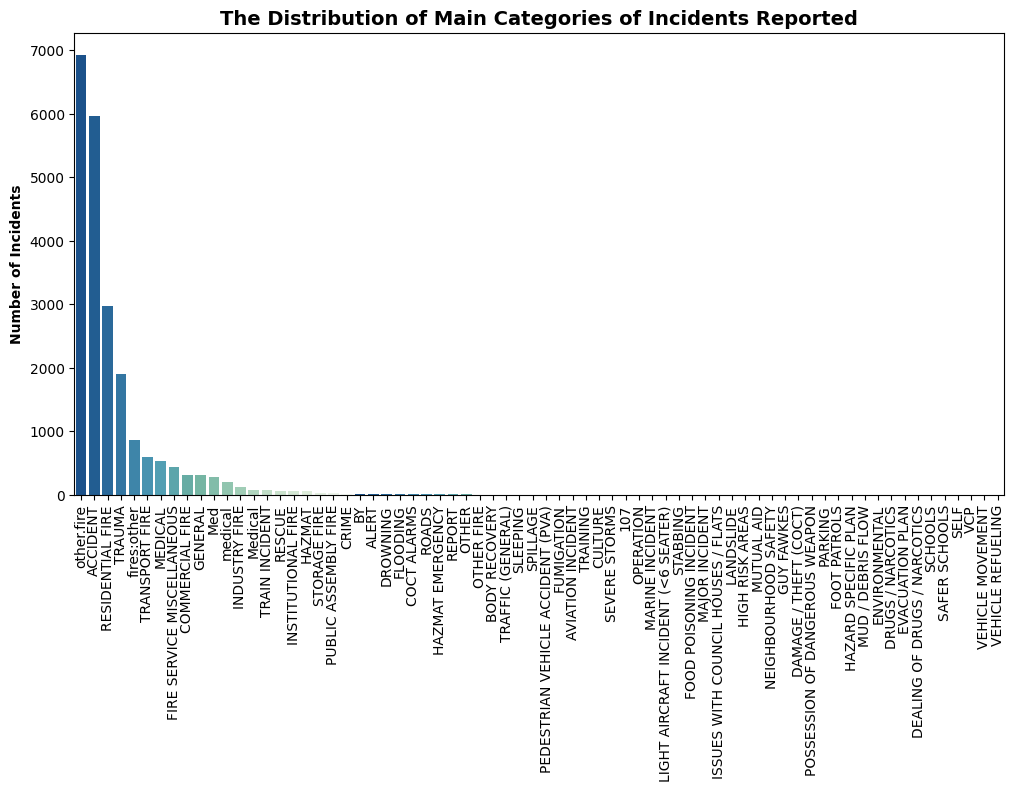

In [12]:
# plot the main category before structural erroe corrections
plt.figure(figsize = (12,6))
sns.countplot(data = df_total_na_removed, x = 'Main_Category', palette = palette_21, order = df_total_na_removed['Main_Category'].value_counts().index)
plt.title('The Distribution of Main Categories of Incidents Reported', fontsize= 14, fontweight = 'bold')
plt.xlabel("")
plt.ylabel('Number of Incidents', fontweight = 'bold')

#sns.countplot(data = df_total_na_removed, x  = 'Main_Category', order = sorted(df_total_na_removed['Main_Category'].unique()))
plt.xticks(rotation=90);  # <-- The semicolon hides the output text


In [13]:
df_clean = df_total_na_removed.copy()

# case-insensitive mapping by converting to uppercase
df_clean['Main_Category'] = df_clean['Main_Category'].str.upper()

category_correction= {
   
    'MED' : 'MEDICAL',
    'MEDICAL': 'MEDICAL',
    'FIRES:OTHER': 'OTHER FIRE',
    'OTHER.FIRE': 'OTHER FIRE',
    'DEALING OF DRUGS / NARCOTICS': 'DRUGS / NARCOTICS',
    'HAZMAT': 'HAZMAT EMERGENCY',
    'BY': 'BY-LAW',
    'SELF': 'SELF-START'
}

df_clean['Main_Category'] = df_clean['Main_Category'].replace(category_correction)

# before and after counts for verification
before_counts = df_total_na_removed["Main_Category"].value_counts()
after_counts = df_clean["Main_Category"].value_counts()

# check if categories are mapped correctly
verification = {
    "MEDICAL": ["med", "Med", "medical", "Medical", "MEDICAL"],
    "OTHER FIRE": ["OTHER FIRE", "fires:other", "other.fire"],
    "DRUGS / NARCOTICS": ["DRUGS / NARCOTICS", "DEALING OF DRUGS / NARCOTICS"],
    "HAZMAT EMERGENCY": ["HAZMAT", "HAZMAT EMERGENCY"],
    "BY-LAW": ["BY", "BY-LAW"],
    "SELF-START": ["SELF", "SELF-START"]
}

for new, old_list in verification.items():
    expected = sum(before_counts.get(old, 0) for old in old_list)
    actual = after_counts.get(new, 0)

    print(f"{new:<22} Expected: {expected:5} | Actual: {actual:5}")



MEDICAL                Expected:  1100 | Actual:  1100
OTHER FIRE             Expected:  7790 | Actual:  7790
DRUGS / NARCOTICS      Expected:     2 | Actual:     2
HAZMAT EMERGENCY       Expected:    63 | Actual:    63
BY-LAW                 Expected:    17 | Actual:    17
SELF-START             Expected:     1 | Actual:     1


In [14]:
# total number of categories after cleaning
count_categories = df_clean['Main_Category'].nunique() #63

print(f"Total number of categories is : {count_categories}")
# number of categories with less than 10 occurances 
counts = df_clean["Main_Category"].value_counts()
rare_occurance = counts[counts < 10].count()
print(f"Numberof categories with fewer than 10 occuarance:{rare_occurance}")

# number of categories with more than 10 occurances
more_than_10 = counts[counts >= 10].count()
print(f"Number categories with more than 10 occurances: {more_than_10}")


Total number of categories is : 63
Numberof categories with fewer than 10 occuarance:42
Number categories with more than 10 occurances: 21


#### **3.7. Final Cleaned Dataset**

The final cleaned dataset consists of 21,971 records and 7 variables. No duplicate records were identified in the dataset. As discussed in the previous section, the 48 missing values in the Subcategory column represent valid observations where an incident was recorded with only a main category and no associated subcategory. These records were therefore retained in the dataset.

The cleaned dataset contains 659 unique suburbs, 63 main incident categories, and 130 subcategories associated with the main categories. Table X summarises the structure and quality of the final cleaned dataset.

In [15]:
def audit(df):
    return pd.DataFrame({
        'Data Types' : df.dtypes,
        "Non-Null Count": df.count(), # listed as an object
        'Missing Values' : df.isnull().sum(),
        'Unique Values' : df.nunique(),
        'Duplicate Rows': df.duplicated().sum()
    })

# convert Count column to numeric
df_clean["Count"] = pd.to_numeric(df_clean["Count"])

audit(df_clean)

,Data Types,Non-Null Count,Missing Values,Unique Values,Duplicate Rows
Month,int64,21971,0,12,0
Day,int64,21971,0,31,0
Suburb,int64,21971,0,659,0
Category,object,21971,0,163,0
Count,float64,21971,0,7,0
Main_Category,object,21971,0,63,0
Subcategory,object,21923,48,130,0


### **4. Data Preparation for Analysis**
####   **4.1 Data Integration**
#####     **4.1.1 Suburb Lookup Table**
The cleaned incident dataset contained 659 unique suburb identifiers, while the suburb lookup table, which maps suburb identifiers to their corresponding suburb names, contained 777 unique suburbs. The difference indicates that some suburbs recorded no incidents during the study period and were therefore not present in the cleaned incident dataset.

The column names in both datasets were standardised before merging. A left join was then performed using the suburb identifier (Suburb_ID) as the key to ensure all suburbs contained in the lookup table were retained in the integrated dataset.

In [16]:
# get unique suburbs in both dataset
print(f"Number of suburbs in df_clean: {df_clean['Suburb'].nunique()}")
print(f"Number of suburbs in data_suburb: {data_suburb['ID'].nunique()}")

# check if ID's in df_clean is in data_suburb  
print(f"Suburbs in lookup table but not in incident dataset: {len(set(data_suburb['ID']) - set(df_clean['Suburb']))}")

# check if ID's in data_suburb is in df_clean
print(f"Suburbs in incident dataset but not in lookup table: {len(set(df_clean['Suburb']) - set(data_suburb['ID']))}")

# renaming columns (ID and Suburb Name) before merging
df_incidents = df_clean.rename(columns = {
    "Suburb" : 'Suburb_ID'
})

df_suburb= data_suburb.rename(columns={
    "ID": "Suburb_ID",
    "Suburb": "Suburb_Name"
})

# merge the dataset by 'Suburb_ID' by left join to return all the data in suburb dataset
df_cpt_suburb = pd.merge(df_suburb,df_incidents, how = 'left', on = 'Suburb_ID' )

df_cpt_suburb.columns
df_cpt_suburb.head(10)
len(df_cpt_suburb)

Number of suburbs in df_clean: 659
Number of suburbs in data_suburb: 777
Suburbs in lookup table but not in incident dataset: 118
Suburbs in incident dataset but not in lookup table: 0


22089

##### **4.1.2 GeoJSON Spatial Dataset**
    

In [17]:
# renaming columns in geojson before merging
df_geojson = data_geojson.rename( columns = { 
    'OBJECTID': 'Suburb_ID', 
    'OFC_SBRB_NAME' : 'Suburb_Name',
    'geometry' : 'Geometry'
})
# merge dataset 
df_final = pd.merge(df_cpt_suburb, df_geojson[['Suburb_ID', 'Geometry']], how = 'left')
print(df_final.isnull().sum())
df_final.head(10)



Suburb_ID          0
Suburb_Name        0
Month            118
Day              118
Category         118
Count            118
Main_Category    118
Subcategory      166
Geometry           0
dtype: int64


,Suburb_ID,Suburb_Name,Month,Day,Category,Count,Main_Category,Subcategory,Geometry
0,774,AAN DE WIJNLANDEN ESTATE,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((18.54126 -33.82946, 18.54124 -33.829..."
1,591,ACACIA PARK,1.0,20.0,ACCIDENT - VECHILE,1.0,ACCIDENT,VECHILE,"POLYGON ((18.52312 -33.90116, 18.52321 -33.901..."
2,591,ACACIA PARK,2.0,24.0,ACCIDENT - VECHILE,1.0,ACCIDENT,VECHILE,"POLYGON ((18.52312 -33.90116, 18.52321 -33.901..."
3,591,ACACIA PARK,2.0,25.0,ACCIDENT - VECHILE,1.0,ACCIDENT,VECHILE,"POLYGON ((18.52312 -33.90116, 18.52321 -33.901..."
4,591,ACACIA PARK,3.0,3.0,ACCIDENT - VECHILE,1.0,ACCIDENT,VECHILE,"POLYGON ((18.52312 -33.90116, 18.52321 -33.901..."
5,591,ACACIA PARK,3.0,7.0,ACCIDENT - VECHILE,1.0,ACCIDENT,VECHILE,"POLYGON ((18.52312 -33.90116, 18.52321 -33.901..."
6,591,ACACIA PARK,3.0,14.0,ACCIDENT - VECHILE,1.0,ACCIDENT,VECHILE,"POLYGON ((18.52312 -33.90116, 18.52321 -33.901..."
7,591,ACACIA PARK,4.0,4.0,ACCIDENT - VECHILE,1.0,ACCIDENT,VECHILE,"POLYGON ((18.52312 -33.90116, 18.52321 -33.901..."
8,591,ACACIA PARK,5.0,6.0,ACCIDENT - VECHILE,1.0,ACCIDENT,VECHILE,"POLYGON ((18.52312 -33.90116, 18.52321 -33.901..."
9,591,ACACIA PARK,5.0,30.0,ACCIDENT - VECHILE,1.0,ACCIDENT,VECHILE,"POLYGON ((18.52312 -33.90116, 18.52321 -33.901..."


#### **4.2 Category Consolidation**
Group categories with ≤ 10 incidents into "OTHER"

                 Main_Category   Count
0                   OTHER FIRE  8779.0
1                     ACCIDENT  6274.0
2             RESIDENTIAL FIRE  3094.0
3                       TRAUMA  2018.0
4                      MEDICAL  1119.0
5               TRANSPORT FIRE   602.0
6   FIRE SERVICE MISCELLANEOUS   449.0
7                      GENERAL   355.0
8              COMMERCIAL FIRE   317.0
9                INDUSTRY FIRE   122.0
10                       OTHER   114.0
11              TRAIN INCIDENT    77.0
12            HAZMAT EMERGENCY    63.0
13                      RESCUE    61.0
14          INSTITUTIONAL FIRE    60.0
15        PUBLIC ASSEMBLY FIRE    28.0
16                STORAGE FIRE    28.0
17                      BY-LAW    18.0
18                       CRIME    18.0
19                       ALERT    16.0


/var/folders/_3/4mz151gx67lc1nvn0d7brq_c0000gn/T/ipykernel_16531/2890235171.py:16: UserWarning: The palette list has more values (21) than needed (20), which may not be intended.
  sns.barplot(data = category_totals, x = 'Main_Category', y = 'Count', hue = 'Main_Category', palette = palette_21, order = df_final['Main_Category'].value_counts().index ) # value_counts() returns categories with count. index returns only categories


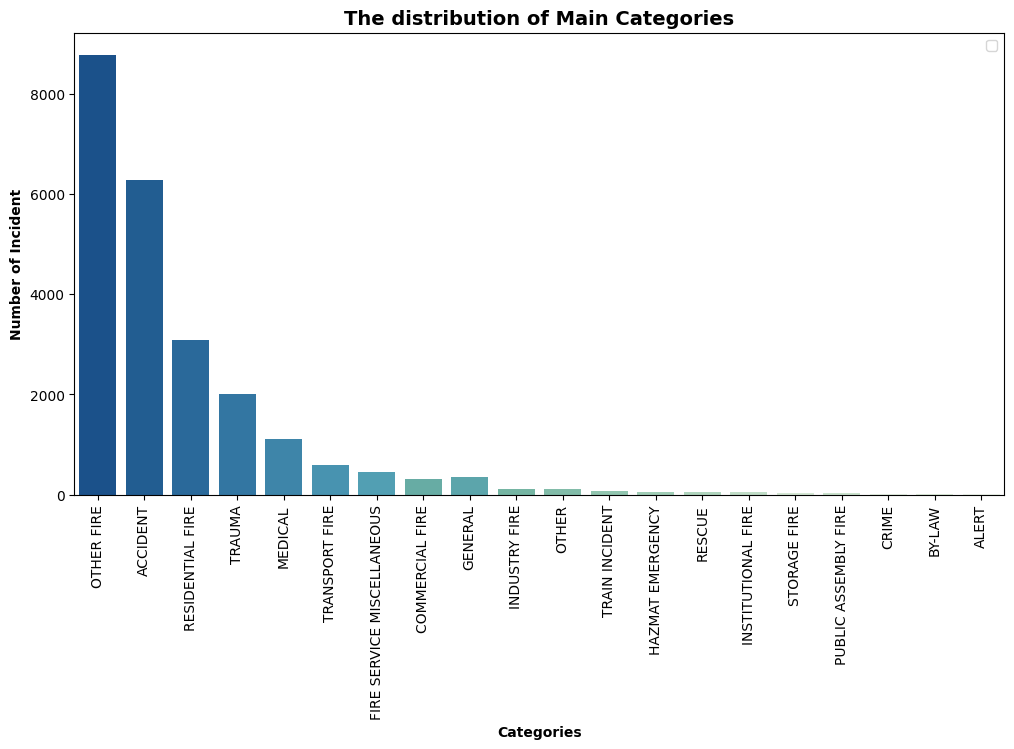

In [ ]:
# combimbe categories with less than recorded incidents
# 1. alculate the total count for each Main_Category
category_sums = df_final.groupby('Main_Category')['Count'].sum()

# 2. mask categories with less than 10 counts
small_categories = category_sums[category_sums <= 10].index 

df_final.loc[df_final['Main_Category'].isin(small_categories), 'Main_Category'] = 'OTHER'

# aggregate by grouping main categories and then sum the count column. Thereafter sort the category highest to lowest, then reset_index to create aggregate dataset with count and main category
category_totals = (df_final.groupby('Main_Category')['Count'].sum().sort_values(ascending=False).reset_index())
print(category_totals)

# plot distibution of categories after consolidation
plt.figure(figsize = (12, 6))
sns.barplot(data = category_totals, x = 'Main_Category', y = 'Count', hue = 'Main_Category', palette = palette_21, order = df_final['Main_Category'].value_counts().index ) # value_counts() returns categories with count. index returns only categories
plt.title('The distribution of Main Categories', fontsize = 14, fontweight = 'bold')
plt.xlabel("Categories", fontweight ='bold')
plt.ylabel("Number of Incident", fontweight = 'bold')
plt.xticks(rotation = 90);
plt.legend("")

plt.savefig("grouped categories.png")

### **4.3 Final Analytical Sataset**

In [32]:
def audit(df):
    return pd.DataFrame({
        'Data Types' : df.dtypes,
        "Non-Null Count": df.count(), # listed as an object
        'Missing Values' : df.isnull().sum(),
        'Unique Values' : df.nunique(),
        'Duplicate Rows': df.duplicated().sum()
    })

# convert Count column to numeric
df_clean["Count"] = pd.to_numeric(df_clean["Count"])

audit(df_final)

,Data Types,Non-Null Count,Missing Values,Unique Values,Duplicate Rows
Suburb_ID,int64,22089,0,777,0
Suburb_Name,object,22089,0,777,0
Month,float64,21971,118,12,0
Day,float64,21971,118,31,0
Category,object,21971,118,163,0
Count,float64,21971,118,7,0
Main_Category,object,21971,118,20,0
Subcategory,object,21923,166,130,0
Geometry,geometry,22089,0,777,0
Month_Name,object,21971,118,12,0


### **5. Exploratory Data Analysis**
The following analysis examines incident patterns across three dimensions: category distribution, temporal trends, and spatial concentration.
#### **5.1 Incidents Categories Distribution**

/var/folders/_3/4mz151gx67lc1nvn0d7brq_c0000gn/T/ipykernel_16531/1171830259.py:9: UserWarning: The palette list has more values (21) than needed (20), which may not be intended.
  sns.barplot(data = categories_total_sums, x = 'Main_Category', y = 'Count', hue = 'Main_Category', palette = palette_21, order = df_clean['Main_Category'].value_counts().index ) # value_counts() returns categories with count. index returns only categories


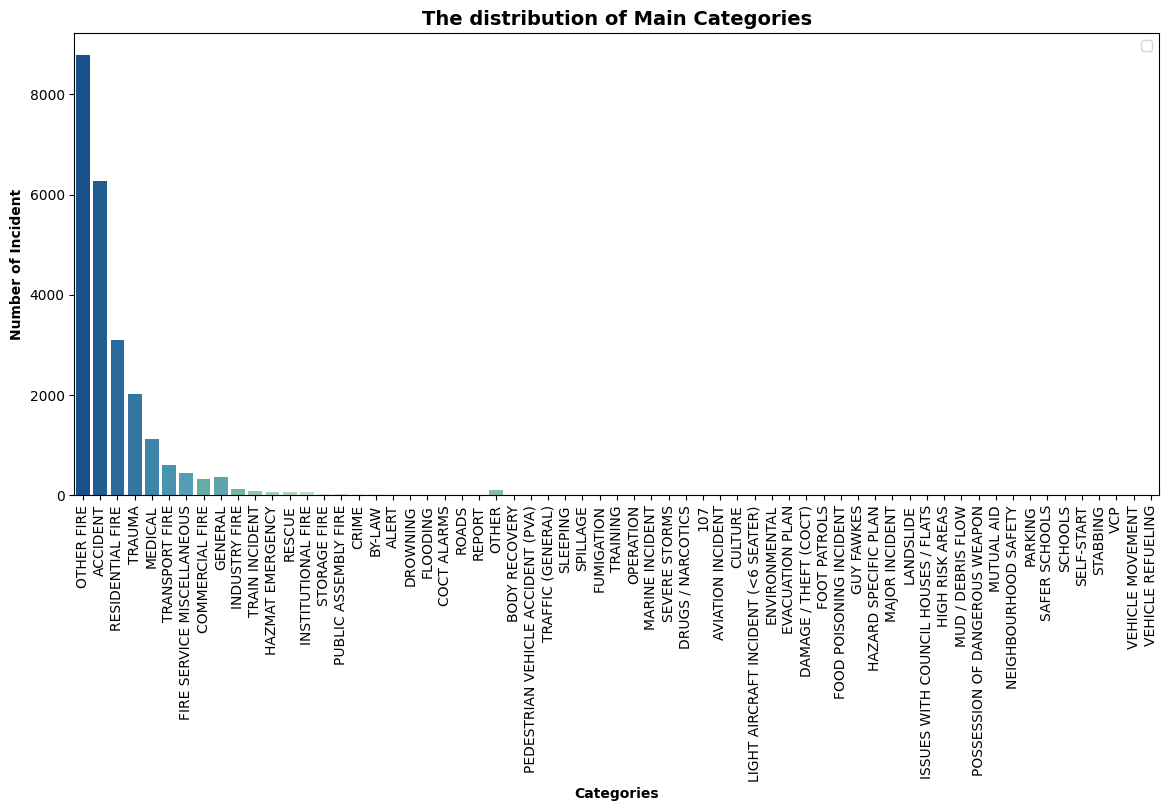

In [19]:
# group records by Main_Category
# sum the Count column to obtain the total incidents per category
# sort categories in descending order of incident count
# reset the index to return a DataFrame with Main_Category and Count columns
categories_total_sums = (df_final.groupby('Main_Category')['Count'].sum().sort_values(ascending=False).reset_index())

# plot distibution of categories
plt.figure(figsize = (14,6))
sns.barplot(data = categories_total_sums, x = 'Main_Category', y = 'Count', hue = 'Main_Category', palette = palette_21, order = df_clean['Main_Category'].value_counts().index ) # value_counts() returns categories with count. index returns only categories
plt.title('The distribution of Main Categories', fontsize = 14, fontweight = 'bold')
plt.xlabel("Categories", fontweight ='bold')
plt.ylabel("Number of Incident", fontweight = 'bold')
plt.xticks(rotation = 90);
plt.legend("")

#### **Key observation**
The distribution of incidents is highly skewed. `OTHER FIRE `is the mostfrequently reported category, followed by `ACCIDENT`, `RESIDENTIAL FIRE`, and `TRAUMA`. Together, these categories account for a substantial proportion of all recorded incidents, while most categories occur relatively infrequently.

#### **5.2 Temporal Analysis**
##### **5.2.1 Incidents by Month**

,Month,Month_Name,Incidents
0,1.0,JANUARY,2474
1,2.0,FEBRUARY,2186
2,3.0,MARCH,2237
3,4.0,APRIL,1831
4,5.0,MAY,1816
5,6.0,JUNE,1709
6,7.0,JULY,1638
7,8.0,AUGUST,1687
8,9.0,SEPTEMBER,1614
9,10.0,OCTOBER,1152


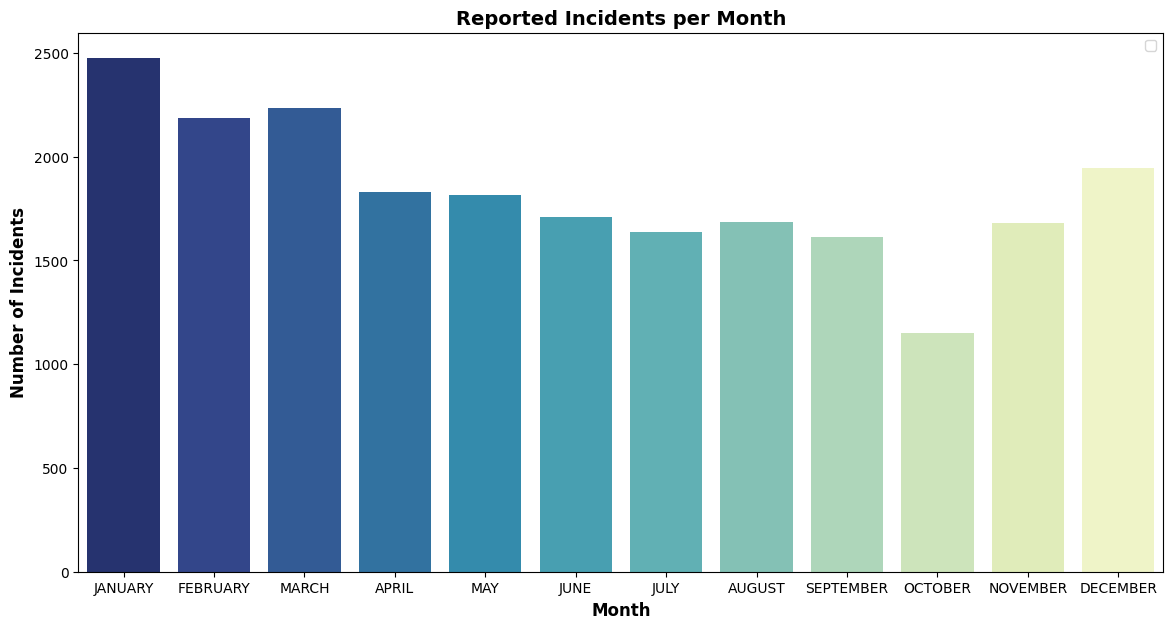

In [21]:
# create a month mapping
month_mapping= { 
    1: 'JANUARY',
    2 : 'FEBRUARY',
    3: 'MARCH',
    4: 'APRIL',
    5: 'MAY',
    6: 'JUNE',
    7: 'JULY', 
    8: 'AUGUST',
    9: 'SEPTEMBER',
    10: 'OCTOBER',
    11: 'NOVEMBER',
    12: 'DECEMBER' }

# create a new column with month name
df_final['Month_Name'] = df_final['Month'].map(month_mapping)

# create monthly counts dataset
monthly_counts = df_final.groupby(['Month', 'Month_Name']) .size().reset_index(name='Incidents').sort_values('Month')

#plot montly reported incidents
plt.figure (figsize = (14,7))
sns.barplot(data = monthly_counts, x = 'Month_Name', y = 'Incidents', estimator=sum, errorbar=None, hue = 'Month_Name', palette = 'YlGnBu_r')
plt.title('Reported Incidents per Month', fontsize = 14,fontweight = 'bold')
plt.xlabel('Month', fontsize = 12,fontweight = 'bold')
plt.ylabel('Number of Incidents', fontsize = 12,fontweight = 'bold')
plt.legend("")
monthly_counts


#### **Key Observations**
January recorded the highest number of reported incidents during the year, followed by March, February, and December. Incident volumes generally declined from January through September before increasing again towards the end of the year. This pattern suggests a possible seasonal effect, with incident activity being higher during the summer months and lower during the winter period.

##### **5.2.2 Seasonal Trends For Major Categories**

/var/folders/_3/4mz151gx67lc1nvn0d7brq_c0000gn/T/ipykernel_16531/1543572670.py:27: UserWarning: The palette list has more values (21) than needed (4), which may not be intended.
  sns.barplot(data = seasonal_counts, x = 'Season', y = 'Incidents', estimator=sum, errorbar=None, hue = 'Season', palette = palette_21)


,Season,Incidents
0,AUTUMN,5884
1,SPRING,4447
2,SUMMER,6606
3,WINTER,5034


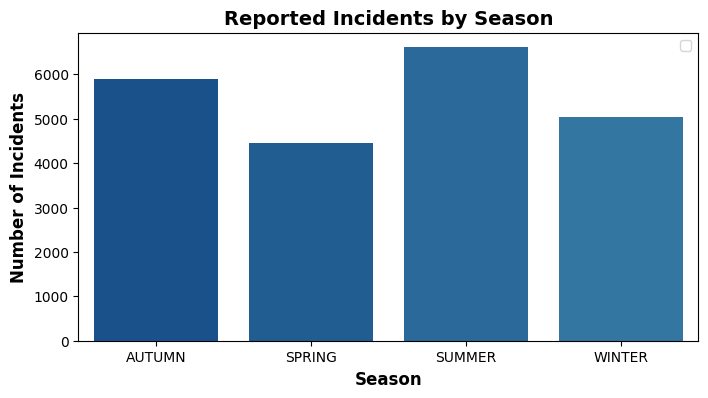

In [22]:
# create a seasonal mapping
season_mapping = {
    'DECEMBER': 'SUMMER',
    'JANUARY': 'SUMMER',
    'FEBRUARY': 'SUMMER',

    'MARCH': 'AUTUMN',
    'APRIL': 'AUTUMN',
    'MAY': 'AUTUMN',

    'JUNE': 'WINTER',
    'JULY': 'WINTER',
    'AUGUST': 'WINTER',

    'SEPTEMBER': 'SPRING',
    'OCTOBER': 'SPRING',
    'NOVEMBER': 'SPRING'
}
# map season into a dataframe
df_final["Season"] = df_final['Month_Name'].map(season_mapping)

# create a seasonal dataset
seasonal_counts = df_final.groupby('Season').size().reset_index(name='Incidents')

#plot seasonal reported incidents
plt.figure (figsize = (8,4))
sns.barplot(data = seasonal_counts, x = 'Season', y = 'Incidents', estimator=sum, errorbar=None, hue = 'Season', palette = palette_21)
plt.title('Reported Incidents by Season', fontsize = 14,fontweight = 'bold')
plt.xlabel('Season', fontsize = 12,fontweight = 'bold')
plt.ylabel('Number of Incidents', fontsize = 12,fontweight = 'bold')
plt.legend("")

seasonal_counts

#### **Key observations**
The highest number of incidents were reported during summer, followed by autumn. Winter recorded more incidents than spring, indicating that seasonal patterns are not uniform across incident types. To investigate this further, the most common incident categories will be analysed by season to identify which categories contribute most to the observed seasonal variation.

#### **5.2.3 Incidents by Day Type**

In [23]:
# distribution of accident subcategories 
# assume data is 2017
# create a date column
df_final['Date'] = pd.to_datetime({
    'year':2017,
    'month': df_final['Month'],
    'day': df_final['Day']
})

# add a weekday column
df_final['Weekday'] = df_final['Date'].dt.day_name()
 
# add day_type column( weekend or weekday)
df_final['Day_Type'] = df_final['Weekday'].isin(['Saturday', 'Sunday']
                                                ).map({True: 'Weekend', False: 'Weekday'})

In [24]:
# create a function to extract major main categories with associated subcategories and plot distributions by a given day
def analyse_major_categories(df,category, color):

    # filter category
    df_category = df[df['Main_Category'] == category]
    # aggregate by day type
    subcategory_daytype = df_category.groupby(['Day_Type', 'Subcategory'])['Count'].sum().sort_values(ascending =False).reset_index()
    print(f"\n{category} Subcategories")
    print(subcategory_daytype)

    color = [palette_21[4], palette_21[10]] 
    # plot bar chart of subcategories by day type
    plt.figure (figsize = (10,6))
    sns.barplot(data = subcategory_daytype, y = 'Subcategory', x = 'Count', estimator=sum, errorbar=None, hue = 'Day_Type', palette = color)
    plt.title(f'Reported {category.title()} Subcategories by Day Type', fontsize = 16,fontweight = 'bold')
    plt.ylabel(f'{category.title()} Subcategories', fontsize = 14,fontweight = 'bold')
    plt.xlabel('Number of Incidents', fontsize = 14,fontweight = 'bold')
    plt.legend(title = 'Day Type', loc ='lower right')
    plt.show()



ACCIDENT Subcategories
  Day_Type Subcategory   Count
0  Weekday     VECHILE  2706.0
1  Weekend     VECHILE  1553.0
2  Weekday  PEDESTRIAN  1340.0
3  Weekend  PEDESTRIAN   675.0


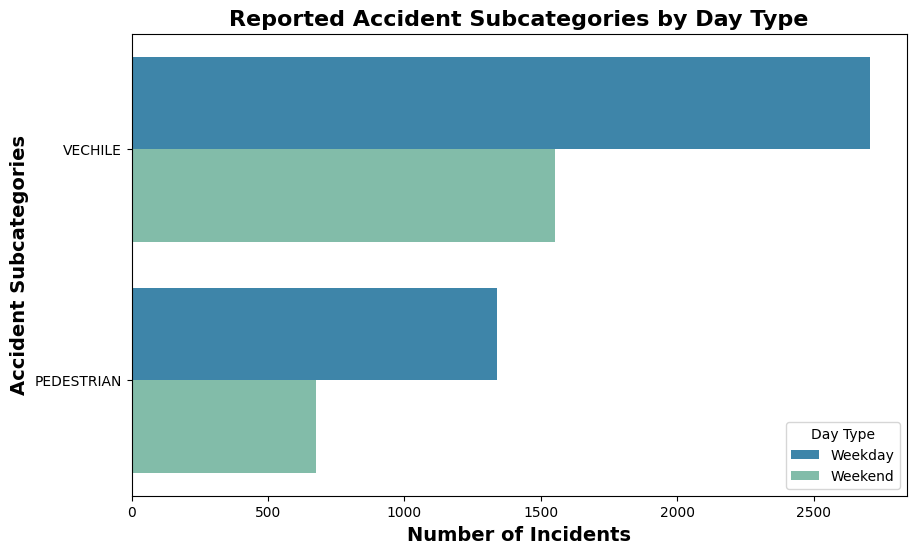

In [25]:
# plot accident category
analyse_major_categories(df_final, 'ACCIDENT', palette_21)

#### **Key Observation**
Vehicle accidents are considerably more common than pedestrian accidents. In addition, accident incidents occur more frequently on weekdays than weekends, suggesting that daily commuting and work-related travel may contribute to higher accident volumes during the week.



MEDICAL Subcategories
   Day_Type                         Subcategory  Count
0   Weekday                   UNABLE TO BREATHE  220.0
1   Weekday                PATIENT UNRESPONSIVE  145.0
2   Weekday                 OBSTETRIC COMPLAINT   81.0
3   Weekend                   UNABLE TO BREATHE   76.0
4   Weekday                  CARDIAC CHEST PAIN   65.0
5   Weekend                PATIENT UNRESPONSIVE   61.0
6   Weekday                         CONVULSIONS   60.0
7   Weekend                 OBSTETRIC COMPLAINT   40.0
8   Weekday        CONFUSION (DIABETIC PATIENT)   37.0
9   Weekend                         CONVULSIONS   37.0
10  Weekday               RESPIRATORY COMPLAINT   37.0
11  Weekday              NEUROLOGICAL COMPLAINT   30.0
12  Weekday                  PAIN (NON-CARDIAC)   24.0
13  Weekend                  CARDIAC CHEST PAIN   18.0
14  Weekend               RESPIRATORY COMPLAINT   18.0
15  Weekday                 ABDOMINAL COMPLAINT   16.0
16  Weekend                 ABDOMINAL COMP

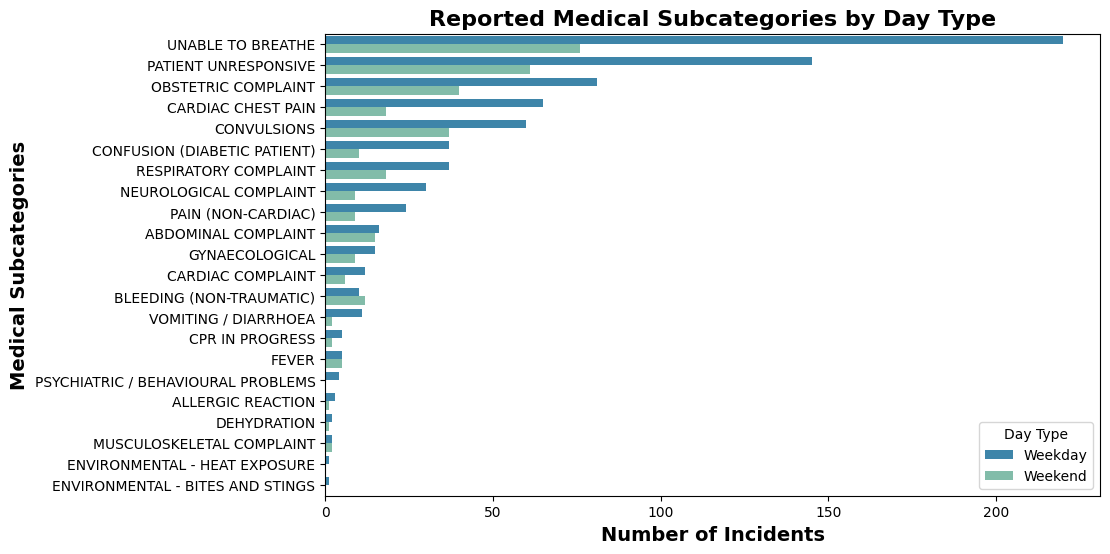

In [26]:
# plot medical category
analyse_major_categories(df_final, 'MEDICAL', palette_21)

#### **Key Observation**
The dominant medical incidents are: Unable to Breathe, Patient Unresponsive, Obstetric Complaint, Cardiac Chest Pain and Convulsions. Medical incidents are dominated by respiratory emergencies and unresponsive patients. Across nearly all medical subcategories, incident volumes are higher on weekdays than weekends, suggesting a greater demand for emergency medical services during the working week.


TRAUMA Subcategories
   Day_Type                       Subcategory  Count
0   Weekend                ASSAULT - PHYSICAL  587.0
1   Weekday                ASSAULT - PHYSICAL  403.0
2   Weekday      ACCIDENTAL INJURY - DOMESTIC  219.0
3   Weekday        ASSAULT - WEAPON (GUNSHOT)  146.0
4   Weekend        ASSAULT - WEAPON (GUNSHOT)  101.0
5   Weekend      ACCIDENTAL INJURY - DOMESTIC   90.0
6   Weekday              BURNS AND CORROSIVES   69.0
7   Weekday                 SELF HARM - OTHER   65.0
8   Weekend          ASSAULT - WEAPON (OTHER)   54.0
9   Weekend              BURNS AND CORROSIVES   39.0
10  Weekday    ACCIDENTAL INJURY - INDUSTRIAL   36.0
11  Weekend                 SELF HARM - OTHER   36.0
12  Weekday          ASSAULT - WEAPON (OTHER)   31.0
13  Weekday                     NEAR DROWNING   22.0
14  Weekday                          BLEEDING   21.0
15  Weekend                     NEAR DROWNING   13.0
16  Weekday        ACCIDENTAL INJURY - SPORTS   12.0
17  Weekday      SELF HA

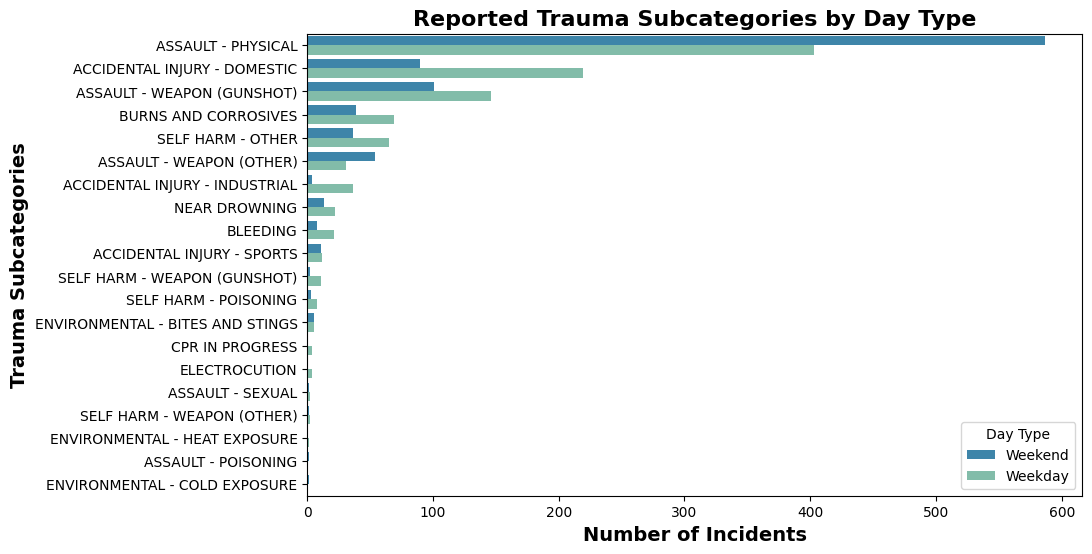

In [27]:
# plot trauma category
analyse_major_categories(df_final, 'TRAUMA', palette_21)

#### **Key Observation**
Physical assault dominates trauma-related incidents, with substantially higher counts than all other subcategories. While most trauma incidents occur more frequently on weekdays, physical assaults and weapon-related assaults are more common on weekends. This suggests that weekend trauma demand is driven largely by interpersonal violence, whereas accidental injuries are more prevalent during the working week.

#### **5.3.2 Seasonal Trends in Fire Incidents**

/var/folders/_3/4mz151gx67lc1nvn0d7brq_c0000gn/T/ipykernel_16531/3580299201.py:36: UserWarning: The palette list has more values (21) than needed (8), which may not be intended.
  sns.barplot(data=df_summer, y='Main_Category', x='Count', estimator=sum, errorbar=None, ax=ax1, hue = 'Main_Category', palette=palette_21, order = fire_order)
/var/folders/_3/4mz151gx67lc1nvn0d7brq_c0000gn/T/ipykernel_16531/3580299201.py:42: UserWarning: The palette list has more values (21) than needed (8), which may not be intended.
  sns.barplot(data = df_autumn, y='Main_Category', x='Count', estimator=sum, errorbar=None, ax = ax2, hue = 'Main_Category', palette = palette_21, order = fire_order)
/var/folders/_3/4mz151gx67lc1nvn0d7brq_c0000gn/T/ipykernel_16531/3580299201.py:48: UserWarning: The palette list has more values (21) than needed (8), which may not be intended.
  sns.barplot(data = df_winter, y='Main_Category', x='Count', estimator=sum, errorbar=None, ax = ax3, hue = 'Main_Category', palette = pal

Text(0, 0.5, '')

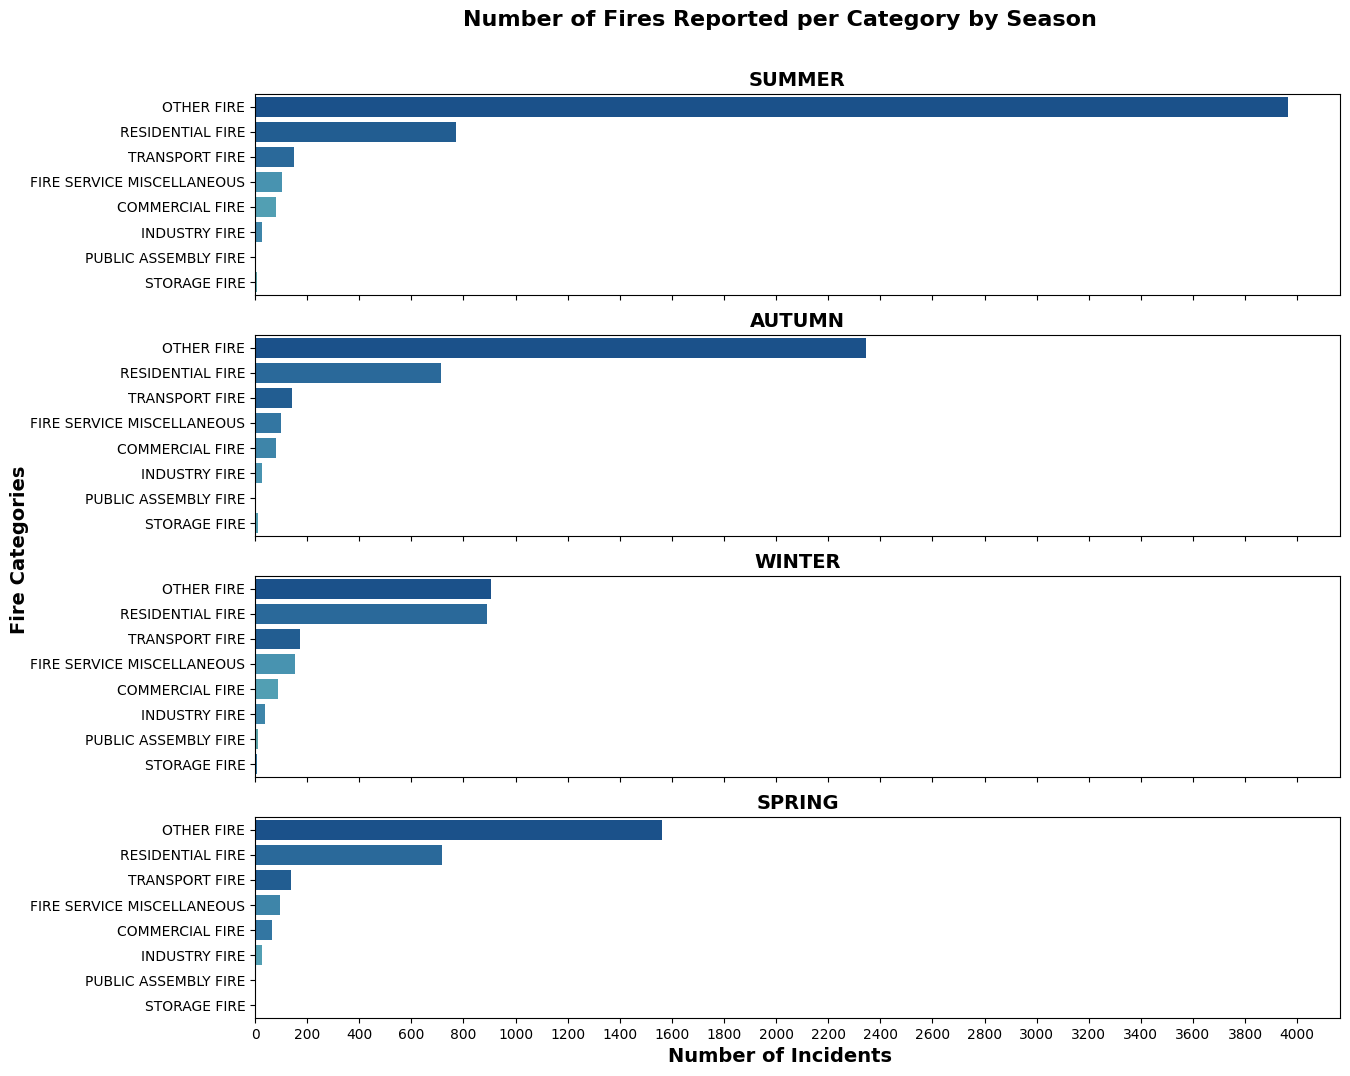

In [28]:
# create fire categories
fire_categories = [
    'COMMERCIAL FIRE',
    'RESIDENTIAL FIRE',
    'INDUSTRY FIRE',
    'TRANSPORT FIRE',
    'FIRE SERVICE MISCELLANEOUS',
    'PUBLIC ASSEMBLY FIRE',
    'STORAGE FIRE',
    'OTHER FIRE']

# create a dataframe of fire categories only
df_fire = df_final[df_final['Main_Category'].isin(fire_categories)]

# order by categories with the highest count
fire_order = df_fire.groupby('Main_Category')['Count'].sum(). sort_values(ascending = False).index

# create seasonal subsets
df_summer = df_fire[df_fire['Season'] == 'SUMMER']
df_autumn = df_fire[df_fire['Season'] == 'AUTUMN']
df_winter = df_fire[df_fire['Season'] == 'WINTER']
df_spring = df_fire[df_fire['Season'] == 'SPRING']

# initialise subplots
fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows = 4, ncols = 1, figsize = (14,12), sharex = True)

# set global titles
fig.supxlabel('Number of Incidents', fontweight ='bold',fontsize=14, y=0.07)
fig.supylabel('Fire Categories', fontweight ='bold',fontsize=14, x=-0.05)
fig.suptitle('Number of Fires Reported per Category by Season', fontsize=16, fontweight='bold', y =0.95)
# set global xtics with maximum of 5000, increang by 200
plt.setp([ax1, ax2, ax3, ax4], xticks =range(0, 5000, 200))

#plot summer sublot
#sns.countplot(data = df_summer, y = 'Main_Category', ax = ax1, hue = 'Main_Category', palette = palette_21)
sns.barplot(data=df_summer, y='Main_Category', x='Count', estimator=sum, errorbar=None, ax=ax1, hue = 'Main_Category', palette=palette_21, order = fire_order)
ax1.set_title('SUMMER', fontweight = 'bold', fontsize=14)
ax1.set_xlabel("")
ax1.set_ylabel("")

#plot autumn sublot
sns.barplot(data = df_autumn, y='Main_Category', x='Count', estimator=sum, errorbar=None, ax = ax2, hue = 'Main_Category', palette = palette_21, order = fire_order)
ax2.set_title('AUTUMN', fontweight = 'bold', fontsize=14)
ax2.set_xlabel("")
ax2.set_ylabel("")

#plot Wwnter sublot
sns.barplot(data = df_winter, y='Main_Category', x='Count', estimator=sum, errorbar=None, ax = ax3, hue = 'Main_Category', palette = palette_21, order = fire_order)
ax3.set_title('WINTER', fontweight = 'bold', fontsize=14)
ax3.set_xlabel("")
ax3.set_ylabel("")

#plot spring sublot
sns.barplot(data = df_spring, y='Main_Category', x='Count', estimator=sum, errorbar=None, ax = ax4, hue = 'Main_Category', palette = palette_21, order = fire_order)
ax4.set_title('SPRING', fontweight = 'bold', fontsize=14)
ax4.set_xlabel("")
ax4.set_ylabel("")


#### **Key Observations**

OTHER FIRE is the dominant fire-related category across all seasons, with the highest number of incidents occurring during summer. Residential fires are consistently the second most common fire category and show relatively stable occurrence throughout the year. Commercial, industrial, institutional, storage, and public assembly fires occur far less frequently and contribute only a small proportion of total fire incidents.

####  **5.3 Spatial Analysis**
##### **5.3.1 Spatial Distribution of Incidents**

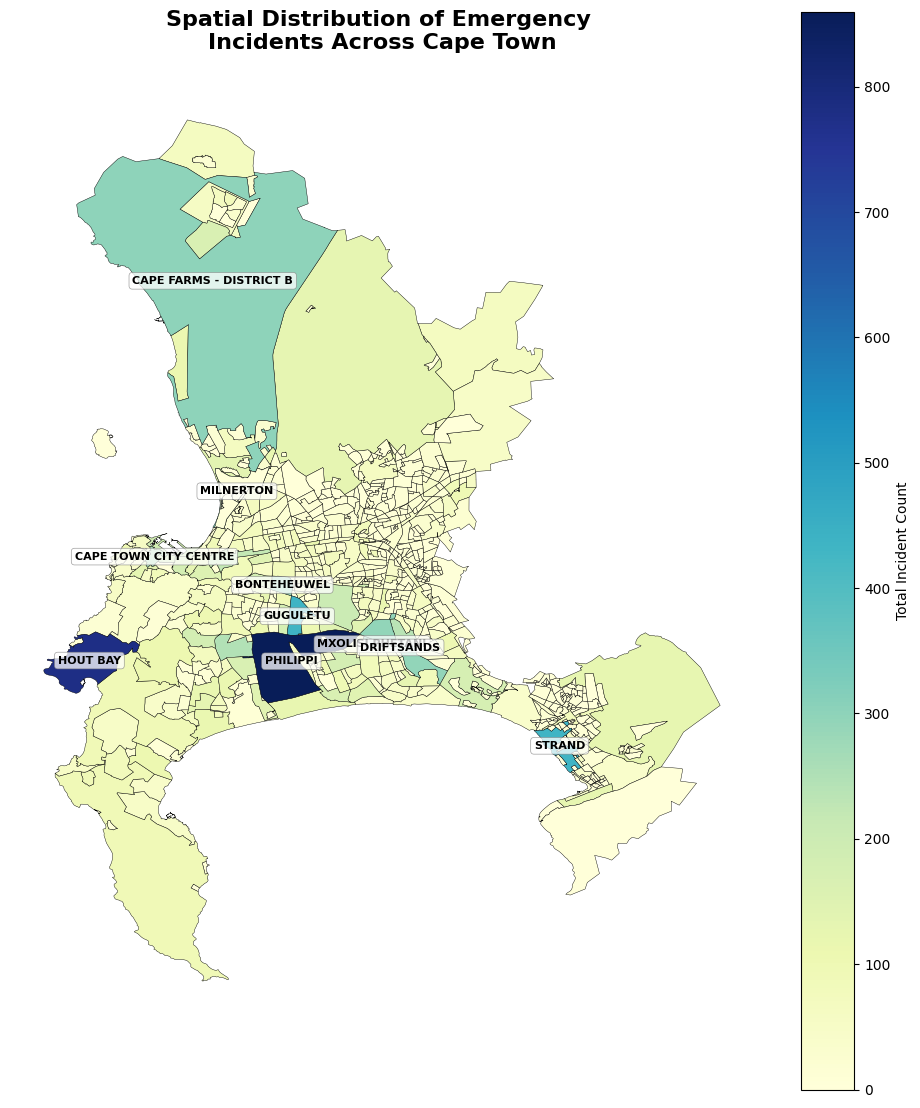

In [29]:
# aggregate by total count of incidents per suburb
suburbs_total = (df_final.groupby(['Suburb_ID', 'Suburb_Name']).agg(Count = ('Count','sum'), Geometry = ('Geometry', 'first')).reset_index())

# convert it back to a GeoDataFrame:
geo_df = gpd.GeoDataFrame(
    suburbs_total,
    geometry='Geometry'
)
# top 10 surburbs
top10_suburbs = geo_df.nlargest(10, 'Count')['Suburb_Name'].tolist()

# Plot of spatial distribution
fig, ax = plt.subplots(1,1, figsize = (12,14))
geo_df.plot(
    column='Count', 
    cmap = 'YlGnBu', 
    legend=True, 
    edgecolor='black', 
    linewidth=0.3, 
    ax=ax,
    legend_kwds={'label': "Total Incident Count"}
)

# filter and overlay Suburb Names for counts > 500
for idx, row in geo_df.iterrows():
    if row['Suburb_Name'] in top10_suburbs:
        # Calculate the geometric center of the suburb to place the text label accurately
        centroid = row['Geometry'].centroid
        
        ax.text(
            x=centroid.x, 
            y=centroid.y, 
            s=row['Suburb_Name'], 
            fontsize=8, 
            fontweight='bold',
            color='black',
            ha='center',       # horizontal alignment: center
            va='center',       # vertical alignment: center
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=0.5, alpha=0.75) # clean background badge
        )

# clean up display
ax.set_title("Spatial Distribution of Emergency \nIncidents Across Cape Town", fontsize=16, fontweight ='bold', pad=20)
ax.axis('off')
plt.show()



##### **Key Observation**
Spatial distribution of emergency incidents across Cape Town suburbs. Darker shades indicate higher incident volumes, while selected hotspot suburbs with the highest incident counts are labelled for reference.

Emergency incidents are unevenly distributed across Cape Town. A small number of suburbs account for substantially higher incident volumes than the rest of the metropolitan area. Notable hotspots include Philippi, Gugulethu, Mxolisi Driftands, Hout Bay and Strand, indicating concentrated demand for emergency response services within these areas.Cape Farms – District B is appearing in your Top 10 because it is geographically huge, not necessarily because it is an urban hotspot.

##### **5.3.2 Suburbs with highest demand?**

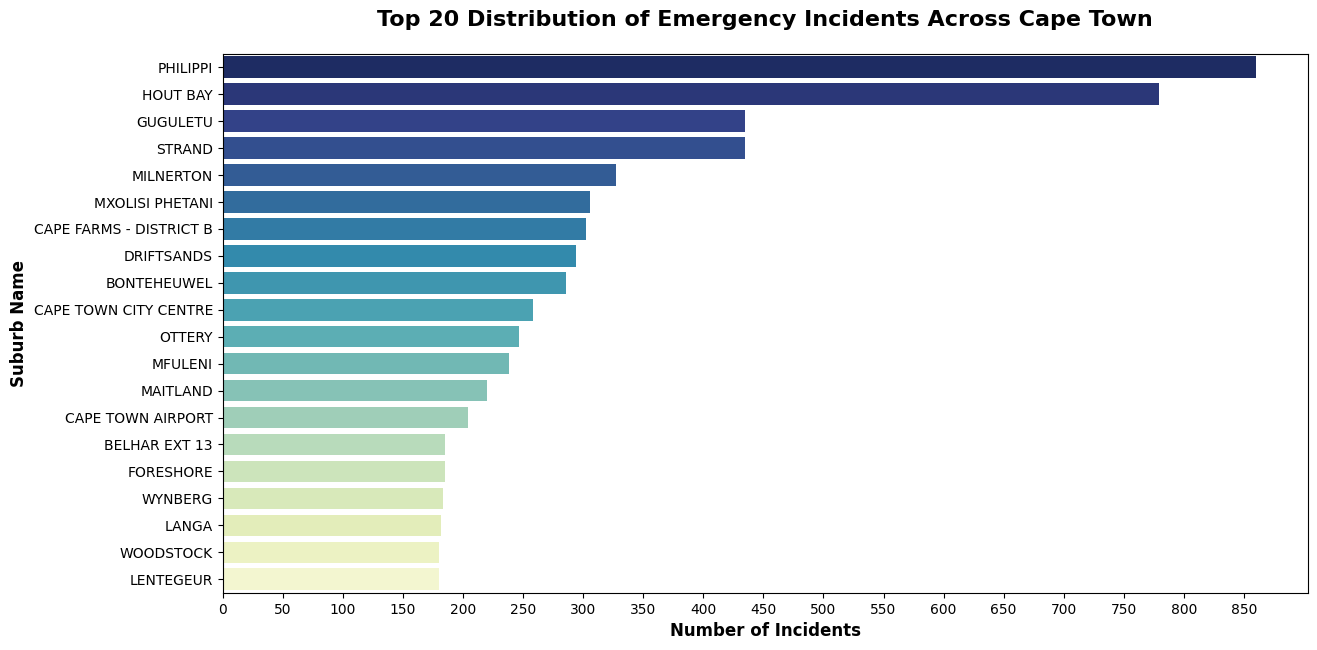

In [30]:
# top 20 district
top20_suburbs = suburbs_total.nlargest(20, 'Count')

# plot a bargraph of top 20 suburbs

fig, ax = plt.subplots(1,1, figsize = (14,7))

sns.barplot(data = top20_suburbs, x = 'Count', y = 'Suburb_Name', estimator=sum, errorbar=None,  hue = 'Suburb_Name', palette = 'YlGnBu_r', ax = ax)
ax.set_xlabel('Number of Incidents', fontsize = 12, fontweight = 'bold')
ax.set_ylabel('Suburb Name', fontsize = 12, fontweight = 'bold')
ax.set_xticks( ticks = range(0,900,50))

# clean up display
ax.set_title("Top 20 Distribution of Emergency Incidents Across Cape Town", fontsize=16, fontweight ='bold', pad=20)
plt.show()

##### **Key Observation**
Emergency incidents are concentrated within a relatively small number of suburbs. Philippi recorded the highest number of incidents, followed by Hout Bay, Gugulethu and Strand.

##### **5.3.3 Top 10 high-incident suburbs?**

Index(['PHILIPPI', 'HOUT BAY', 'GUGULETU', 'STRAND', 'MILNERTON',
       'MXOLISI PHETANI', 'CAPE FARMS - DISTRICT B', 'DRIFTSANDS',
       'BONTEHEUWEL', 'CAPE TOWN CITY CENTRE'],
      dtype='object', name='Suburb_Name')

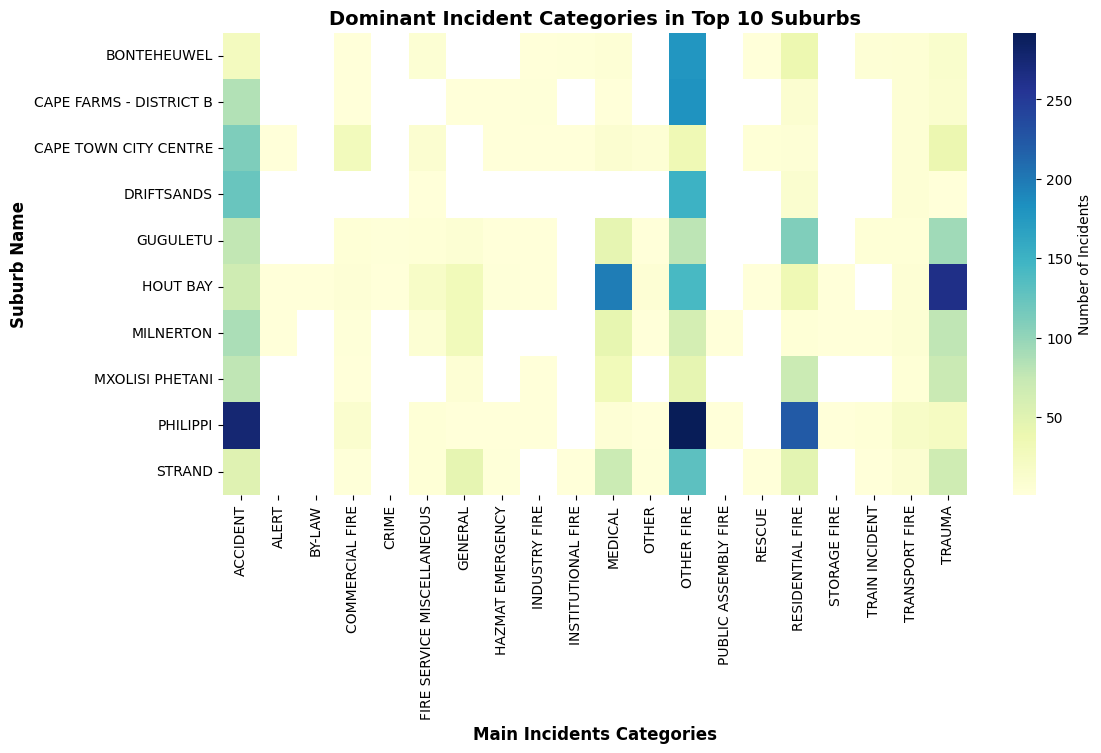

In [31]:
# top 10 suburbs 
top10_suburbs = geo_df.groupby('Suburb_Name')['Count'].sum().nlargest(10).index

# data grouped by suburb name and main categories
top10_incidents = df_final.groupby(['Suburb_Name', 'Main_Category'])['Count'].sum().reset_index()

# filter top 10 suburbs in the data grouped by suburb name and main categories 
heatmap_df = top10_incidents[top10_incidents['Suburb_Name'].isin(top10_suburbs)]

# pivot wider the heatmap data
heatmap_df = heatmap_df.pivot(index = 'Suburb_Name', columns = 'Main_Category', values = 'Count')

# plot heatmap
fig, ax = plt.subplots(1,1,figsize = (12,6))

sns.heatmap(data = heatmap_df, cmap = 'YlGnBu', ax = ax, cbar_kws = {'orientation': 'vertical', 'label': 'Number of Incidents'}
)
ax.set_xlabel('Main Incidents Categories', fontsize = 12, fontweight ='bold')
ax.set_ylabel('Suburb Name', fontsize = 12, fontweight ='bold')

plt.title('Dominant Incident Categories in Top 10 Suburbs', fontsize = 14, fontweight='bold')

top10_suburbs

##### **Key Observations**
Analysis of the top ten suburbs revealed distinct incident profiles across Cape Town. Philippi, which recorded the highest number of incidents overall, was primarily characterised by accidents, other fires and residential fires. Hout Bay displayed a more diverse incident profile, with medical emergencies, trauma incidents and other fires contributing significantly to the overall emergency service demand.

Cape Town City Centre showed a concentration of accidents and commercial fire incidents, reflecting the high levels of commercial activity and daily movement within the area. However, Cape Farms – District B was dominated by fire-related incidents, particularly other fires.

Gugulethu, Bonteheuwel, Mxolisi Phetani and Philippi exhibited similar patterns, with accidents, residential fires and trauma incidents featuring prominently. These suburbs collectively highlight the importance of fire, trauma and accident-related emergencies in driving service demand within densely populated residential communities.



#### **5.4 Key findings 

Analysis of emergency incidents reported across Cape Town reveals clear patterns in the type, timing, and location of incidents placing demand on emergency services.

Other Fire was the most frequently reported category, followed by Accident, Residential Fire, and Trauma, together accounting for the substantial majority of all recorded incidents.

Incident volumes peaked during summer, driven largely by fire-related activity, before declining through mid-year and rising again towards December. Residential fires were the exception, occurring consistently throughout the year regardless of season.

Weekday and weekend patterns differed by incident type. Accidents and medical emergencies were more common on weekdays, while physical and weapon-related assaults dominated weekend trauma demand.

Emergency incidents were concentrated within a small number of suburbs rather than evenly distributed across the city. Philippi recorded the highest overall volume, followed by Hout Bay, Gugulethu, and Strand. Densely populated residential suburbs were characterised by accidents, fires, and trauma, while the City Centre showed a concentration of accidents and commercial fires reflecting its high daily movement and commercial activity.


#### **5.5 Business Recommendations**
The analysis suggests that emergency service resources should be allocated according to the dominant incident types within each suburb and seasonal demand patterns. Rather than adopting a uniform approach across Cape Town, resource planning should be tailored to the specific risks faced by different communities.

Trauma-related incidents were found to be concentrated in densely populated residential suburbs such as Philippi and Gugulethu, indicating a need for adequate emergency medical and trauma response capacity in these areas. Accident-related incidents were particularly prominent in the Cape Town City Centre, likely due to high levels of commercial activity, traffic movement, and pedestrian volumes, especially during weekdays.

Fire-related incidents, particularly Other Fire, were the most prevalent category across many suburbs and showed increased occurrence during the summer months. The City could therefore strengthen fire prevention initiatives and strategically position firefighting resources in high-risk areas during periods of elevated fire activity. Residential fires also represented a significant proportion of incidents in several suburbs and occurred consistently throughout the year, highlighting the importance of maintaining adequate fire response capacity across residential communities.